In [3]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from Grape import GrapeLBFGS as gp
from Grape import *
from helpful_functions import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def make_H(Nc: int, Nq: int, g: float, alpha: float) -> tuple[qt.Qobj, qt.Qobj]:
    """
    Build drift and control Hamiltonians for detuning control:

      H(t) = H_d + Δ(t) * H_c

    where:
      - H_d contains JC exchange + transmon Kerr anharmonicity
      - H_c is the transmon number operator n_q = a_q† a_q
    Tensor order: cavity ⊗ transmon.

    Returns:
      H_d, H_c
    """
    a_r = qt.tensor(qt.destroy(Nc), qt.qeye(Nq))   # cavity lowering
    a_q = qt.tensor(qt.qeye(Nc), qt.destroy(Nq))   # transmon lowering
    n_q = a_q.dag() * a_q

    H_d = g * (a_q.dag()*a_r + a_q*a_r.dag())
    H_d += (alpha/2.0) * (a_q.dag()*a_q.dag()*a_q*a_q)

    H_c = n_q
    return H_d, H_c


In [16]:
Nr_subspace_dim = 5          # cavity dim: levels 0...Nc-1 only for unitary target via projection
Nq_subspace_dim = 2          # qubit dim: levels 0...Nq-1 only for unitary target via projection
Nc_big = 10     # total cavity dim: includes higher levels
Nq_big = 5      # total qubit dim: includes higher levels

g = 1 * 2*np.pi        # coupling (angular units)
alpha = -160 * 2*np.pi # transmon anharmonicity (angular units)
dressed_detuning = 155 * 2*np.pi  # detuning between cavity and transmon for adiabetic dressed frame 

drive_parameters = {
    'N_c': Nc_big,
    'N_q': Nq_big,   
    'detuning': dressed_detuning,  # qubit-resonator detuning in angular frequency
    'gbs': g,       # qubit-resonator coupling strength in angular frequency
}
results = dchi_H(drive_parameters, alpha)

w_r_dressed = results['dressed_operators']['w_r_dressed']
w_q_dressed = results['dressed_operators']['w_q_dressed']

evecs_qobj = results['sorted_dict']['evecs_qobj']
chi = results['chi_dict']['chi_list'][0]

a_r = results['Hamiltonian_dict']['a_r']
a_q = results['Hamiltonian_dict']['a_q']
n_r = a_r.dag() * a_r
n_q = a_q.dag() * a_q

U_cross_target = (-1j * np.pi * (n_r * n_q)).expm() # this is the cross-Kerr needed
adiabatic_unitary = evecs_qobj # transforms from bare to dressed frame

gauge_ops = [n_r, n_q] # gauge ops for bare frame
projector = projector_onto_states([qt.tensor(qt.fock(Nc_big, n_r), qt.fock(Nq_big, n_q)) for n_r in range(Nr_subspace_dim) for n_q in range(Nq_subspace_dim)])
T_gate = np.pi/chi  # gate time for cross-Kerr pi. this is positive

In [17]:
import threading, sys, io
from collections import deque
import ipywidgets as widgets
from IPython.display import display

n_steps = 100
dt = T_gate / n_steps + 0.1
det_min = 1.0 * 2*np.pi
det_max = 1000.0 * 2*np.pi

opt = gp(
    H_drift = make_H(Nc_big, Nq_big, g, alpha)[0],
    H_controls = [make_H(Nc_big, Nq_big, g, alpha)[1]],
    U_target = U_cross_target,
    dt = dt,
    n_steps = n_steps,
    cost_type= "projected",
    projector = projector,
    derivative= "frechet",
    gauge_ops=gauge_ops,
    adiabatic_unitary=adiabatic_unitary
)

opt.add_smoothness_penalty(lam=1e-5)

pulses0 = dressed_detuning * np.ones((n_steps, 1))
theta0  = [w_r_dressed * T_gate, w_q_dressed * T_gate]

scipy_options = {"gtol": 1e-8, "ftol": 1e-9, "maxls": 50}

# ── Rolling-buffer stdout that keeps the last 20 lines ────────────
class _RollingStream:
    def __init__(self, textarea, maxlines=20):
        self._buf  = deque(maxlen=maxlines)
        self._ta   = textarea
        self._line = ""
    def write(self, text):
        for ch in text:
            if ch == "\n":
                if self._line:
                    self._buf.append(self._line)
                self._line = ""
            else:
                self._line += ch
        self._ta.value = "\n".join(self._buf)
    def flush(self):
        pass

# ── Widgets ───────────────────────────────────────────────────────
log_area   = widgets.Textarea(layout=widgets.Layout(width="420px", height="340px"),
                              disabled=True)
btn_cancel = widgets.Button(description="Cancel", button_style="danger",
                            layout=widgets.Layout(width="100px"))
status_lbl = widgets.Label("Running…")

def _on_cancel(_):
    opt.cancel()
    btn_cancel.disabled = True
    status_lbl.value = "Cancelling after this iteration…"

btn_cancel.on_click(_on_cancel)
display(widgets.VBox([widgets.HBox([btn_cancel, status_lbl]), log_area]))

# ── Optimization thread ───────────────────────────────────────────
def _run():
    global out
    stream = _RollingStream(log_area, maxlines=20)
    old_stdout = sys.stdout
    sys.stdout = stream
    try:
        out = opt.optimize(
            maxiter=4000,
            pulse_bounds=[(det_min, det_max)],
            pulses0=pulses0,
            theta0=theta0,
            scipy_options=scipy_options,
        )
    finally:
        sys.stdout = old_stdout
    f = opt.fidelity(out["pulses_opt"], theta=out["theta_opt"])
    tag = "Cancelled" if out.get("cancelled") else "Done"
    status_lbl.value = f"{tag} — fidelity: {f:.6f}"
    btn_cancel.disabled = True

threading.Thread(target=_run, daemon=True).start()


Final fidelity: 0.9979527791227167


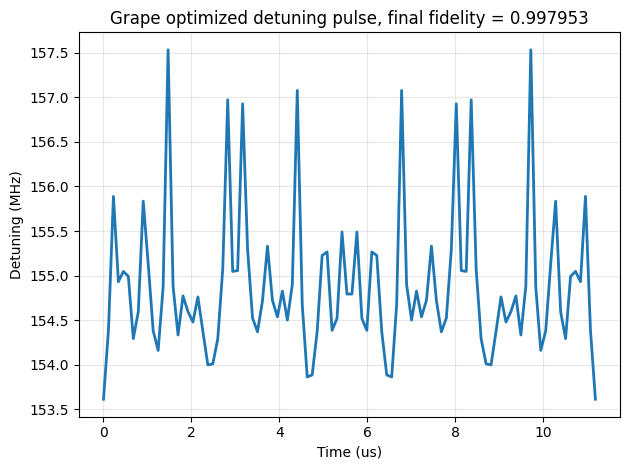

dressed_detuning (MHz): 155.0


In [18]:
# --- Final fidelity ---
F_final = opt.fidelity(out["pulses_opt"], theta=out["theta_opt"])
print("Final fidelity:", F_final)

t_us = np.arange(n_steps) * dt  # dt is in us in your codebase (T_gate/n_steps)
pulse_MHz = out["pulses_opt"][:, 0] / (2*np.pi)  # convert rad/ns -> MHz

plt.figure()
plt.plot(t_us, pulse_MHz, linewidth=2)

plt.xlabel("Time (us)")
plt.ylabel("Detuning (MHz)")
plt.title(f"Grape optimized detuning pulse, final fidelity = {F_final:.6f}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("dressed_detuning (MHz):", dressed_detuning/(2*np.pi))

In [19]:
opt.save_results("Grape_results/run4_weird_adiabatic.npz", out, extra_params={
    "drive_parameters": drive_parameters,
    "alpha": alpha})

In [20]:
result_file = "Grape_results/run4_weird_adiabatic.npz"

q = load_qobjs(result_file)
pulses0, theta0 = load_pulses_theta(result_file)
parameters_dict = load_parameters_dict(result_file)

H0 = q["H_drift"]
Hc = q["H_controls"]
Ut = q["U_target"]
P  = q["projector"]
gauge_ops = q["gauge_ops"]
adiabatic_unitary = q["adiabatic_unitary"]

U_final = propagate(H0, Hc, dt = parameters_dict["dt"], pulses = pulses0)
G = gauge_unitary(gauge_ops, theta0)
g_unitary = G * adiabatic_unitary.dag() * U_final * adiabatic_unitary

# write unitary in terms of the dressed basis
# unitary_dressed = evecs_qobj.dag() * g_unitary * evecs_qobj

fidelity = unitary_projected_fidelity(Ut, g_unitary, P)
print("Fidelity check:", fidelity)

Fidelity check: 0.9979527791225489


In [21]:
import io
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from qutip import Bloch
import ipywidgets as widgets
from IPython.display import display

result_file = "Grape_results/run4_weird_adiabatic.npz"
# ── Load saved GRAPE pulse & operators ───────────────────────────
q_saved = load_qobjs(result_file)
p_grape, th_grape = load_pulses_theta(result_file)
p_dict  = load_parameters_dict(result_file)

H_drift_ev = q_saved["H_drift"]
H_ctrl_ev  = q_saved["H_controls"]

dt_ev = p_dict["dt"]
drive_parameters = p_dict["drive_parameters"]
alpha            = p_dict["alpha"]

results           = dchi_H(drive_parameters, alpha)
evecs_qobj        = results['sorted_dict']['evecs_qobj']
w_q_dressed       = results['dressed_operators']['w_q_dressed']

nsteps              = len(p_grape)
dressed_detuning_ev = drive_parameters['detuning']

print(f"dressed_detuning = {dressed_detuning_ev / (2*np.pi):.4f} MHz")
print(f"w_q_dressed      = {w_q_dressed      / (2*np.pi):.4f} MHz")

p_unopt = dressed_detuning_ev * np.ones((nsteps, 1))

# ── Qubit Pauli operators in the bare 0,1 subspace ───────────────
def _ket_bra(r, c, N):
    m = np.zeros((N, N), dtype=complex); m[r, c] = 1.0
    return qt.Qobj(m)

sx_q      = _ket_bra(0, 1, Nq_big) + _ket_bra(1, 0, Nq_big)
sy_q      = -1j * _ket_bra(0, 1, Nq_big) + 1j * _ket_bra(1, 0, Nq_big)
sz_q      = _ket_bra(0, 0, Nq_big) - _ket_bra(1, 1, Nq_big)
proj_01_q = _ket_bra(0, 0, Nq_big) + _ket_bra(1, 1, Nq_big)

# ── Initial states in dressed basis: evecs_qobj * |n, +x>_bare ───
photon_nums = list(range(5))
psi0s = [
    evecs_qobj * qt.tensor(qt.basis(Nc_big, n),
                           (qt.basis(Nq_big, 0) + qt.basis(Nq_big, 1)).unit())
    for n in photon_nums
]

# ── Step-by-step propagation ──────────────────────────────────────
def compute_bloch_trajectories(pulses, H_drift, H_ctrls, dt, psi0_list, label=""):
    ns = len(pulses)
    nb = len(psi0_list)
    bvec    = np.zeros((nb, ns + 1, 3))
    leakage = np.zeros((nb, ns + 1))
    psis = [p.copy() for p in psi0_list]

    def _measure(psi_dressed):
        psi_bare = evecs_qobj.dag() * psi_dressed
        rho_q = psi_bare.ptrace([1])
        return ([qt.expect(sx_q, rho_q).real,
                 qt.expect(sy_q, rho_q).real,
                 qt.expect(sz_q, rho_q).real],
                1.0 - qt.expect(proj_01_q, rho_q).real)

    for i, psi in enumerate(psis):
        bvec[i, 0], leakage[i, 0] = _measure(psi)

    for k in range(ns):
        H_k = H_drift + pulses[k, 0] * H_ctrls[0]
        U_k = (-1j * H_k * dt).expm()
        for i in range(nb):
            psis[i] = U_k * psis[i]
            bvec[i, k + 1], leakage[i, k + 1] = _measure(psis[i])
        if (k + 1) % 10 == 0:
            print(f"  {label} step {k+1}/{ns}", end="\r")
    print(f"  {label} done.            ")
    return bvec, leakage

print("Evolving GRAPE case…")
bv_grape, leak_grape = compute_bloch_trajectories(p_grape, H_drift_ev, H_ctrl_ev, dt_ev, psi0s, "GRAPE")
print("Evolving unoptimised case…")
bv_unopt, leak_unopt = compute_bloch_trajectories(p_unopt, H_drift_ev, H_ctrl_ev, dt_ev, psi0s, "Unopt")
print("All done.")

# ── Rotating-frame Bloch vectors ─────────────────────────────────
def to_rotating_frame(bvec, freq, dt):
    t = np.arange(bvec.shape[1]) * dt
    c, s = np.cos(freq * t), -np.sin(freq * t)
    rf = bvec.copy()
    rf[:, :, 0] =  bvec[:, :, 0] * c + bvec[:, :, 1] * s
    rf[:, :, 1] = -bvec[:, :, 0] * s + bvec[:, :, 1] * c
    return rf

bv_grape_rf = to_rotating_frame(bv_grape, w_q_dressed, dt_ev)
bv_unopt_rf = to_rotating_frame(bv_unopt, w_q_dressed, dt_ev)

frame_options = {
    'Lab frame':      (bv_grape,    bv_unopt),
    'Rotating frame': (bv_grape_rf, bv_unopt_rf),
}

# ── Pre-render all frames to PNG bytes ───────────────────────────
# Playback then just swaps bytes in an Image widget — runs at any speed.
def _render_frame(step, frame_name):
    bvecs_g, bvecs_u = frame_options[frame_name]
    cases = [("GRAPE optimised", bvecs_g), ("Unoptimised flat Δ", bvecs_u)]

    fig = plt.figure(figsize=(18, 8))
    fig.suptitle(f'{frame_name} — t = {step * dt_ev:.3f} μs  (step {step} / {nsteps})', fontsize=12)

    for row, (case_label, bvecs) in enumerate(cases):
        for col in range(5):
            ax = fig.add_subplot(2, 5, row * 5 + col + 1, projection='3d')
            b = Bloch(fig=fig, axes=ax)
            b.vector_color = ['tomato']
            b.point_color  = ['steelblue']
            b.point_marker = ['.']
            b.point_size   = [6]
            b.frame_alpha  = 0.05
            b.sphere_alpha = 0.05

            x = bvecs[col, :step + 1, 0]
            y = bvecs[col, :step + 1, 1]
            z = bvecs[col, :step + 1, 2]
            b.add_points([x, y, z], meth='l')
            b.add_vectors([float(x[-1]), float(y[-1]), float(z[-1])])
            b.make_sphere()

            title = f'n={col}' if row > 0 else f'{case_label}\nn={col}'
            ax.set_title(title, fontsize=8, pad=1)

    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=72, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return buf.read()

print("Pre-rendering frames…")
all_frames = {name: [] for name in frame_options}
for step in range(nsteps + 1):
    for name in frame_options:
        all_frames[name].append(_render_frame(step, name))
    if (step + 1) % 10 == 0:
        print(f"  {step + 1}/{nsteps + 1}", end="\r")
print("Pre-rendering done.")

# ── Animated viewer: Image widget swaps pre-rendered PNGs ────────
img_widget = widgets.Image(value=all_frames['Lab frame'][0], format='png',
                           layout=widgets.Layout(width='100%'))

play = widgets.Play(
    value=0, min=0, max=nsteps, step=1,
    interval=100, description='',
)
speed_sl = widgets.IntSlider(
    value=100, min=20, max=1000, step=10,
    description='ms/frame',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px'),
)
frame_dd = widgets.Dropdown(
    options=list(frame_options.keys()),
    value='Lab frame', description='Frame:',
)

widgets.jslink((speed_sl, 'value'), (play, 'interval'))

def _update(change):
    img_widget.value = all_frames[frame_dd.value][play.value]

play.observe(_update, names='value')
frame_dd.observe(_update, names='value')

display(widgets.VBox([
    widgets.HBox([play, speed_sl, frame_dd]),
    img_widget,
]))


dressed_detuning = 155.0000 MHz
w_q_dressed      = 155.0065 MHz
Evolving GRAPE case…
  GRAPE done.            
Evolving unoptimised case…
  Unopt done.            
All done.
Pre-rendering frames…
Pre-rendering done.


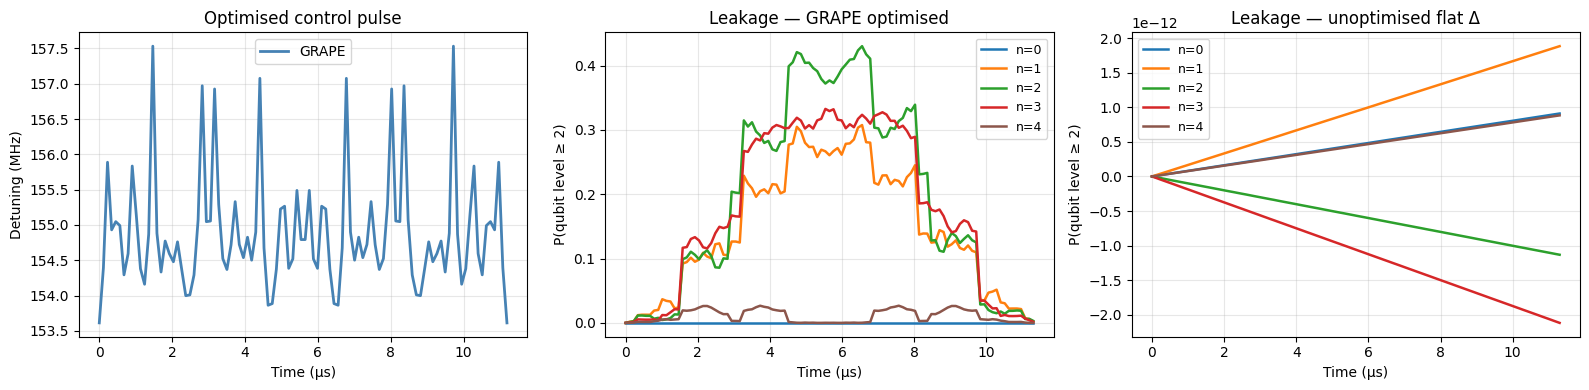

In [22]:
import matplotlib.pyplot as plt
import numpy as np

t_steps = np.arange(nsteps + 1) * dt_ev   # time axis for states (n_steps+1 points)
t_pulse = np.arange(nsteps) * dt_ev        # time axis for pulse  (n_steps points)

colors = plt.cm.tab10(np.linspace(0, 0.5, 5))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Optimised pulse ───────────────────────────────────────────────
axes[0].plot(t_pulse, p_grape[:, 0] / (2 * np.pi), lw=2, color='steelblue', label='GRAPE')
# axes[0].axhline(dressed_detuning / (2 * np.pi), color='gray', lw=1.2,
#                 linestyle='--', label='flat Δ')
axes[0].set_xlabel('Time (μs)')
axes[0].set_ylabel('Detuning (MHz)')
axes[0].set_title('Optimised control pulse')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Leakage — GRAPE ───────────────────────────────────────────────
for n in photon_nums:
    axes[1].plot(t_steps, leak_grape[n], color=colors[n], lw=1.8, label=f'n={n}')
axes[1].set_xlabel('Time (μs)')
axes[1].set_ylabel('P(qubit level ≥ 2)')
axes[1].set_title('Leakage — GRAPE optimised')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Leakage — unoptimised ─────────────────────────────────────────
for n in photon_nums:
    axes[2].plot(t_steps, leak_unopt[n], color=colors[n], lw=1.8, label=f'n={n}')
axes[2].set_xlabel('Time (μs)')
axes[2].set_ylabel('P(qubit level ≥ 2)')
axes[2].set_title('Leakage — unoptimised flat Δ')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
